In [135]:
import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from optuna.integration import LightGBMPruningCallback
from plotly.io import show
import optuna.visualization as ov
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

In [136]:
#importazione dei dataset
df = pd.read_csv("train.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [137]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [138]:
object_df = df.select_dtypes(include=[np.object_])
object_df.nunique()

gender               3
ethnicity            5
education_level      4
income_level         5
smoking_status       3
employment_status    4
dtype: int64

In [139]:
unique_values = object_df.apply(lambda x: x.unique())
print(unique_values)

gender                                         [Female, Male, Other]
ethnicity                     [Hispanic, White, Asian, Black, Other]
education_level      [Highschool, Graduate, Postgraduate, No formal]
income_level         [Lower-Middle, Upper-Middle, Low, Middle, High]
smoking_status                              [Current, Never, Former]
employment_status           [Employed, Retired, Student, Unemployed]
dtype: object


In [140]:
income_level_to_value = {'Lower-Middle' : 2, 'Upper-Middle':4, 'Low': 1, 'Middle':3, 'High':5}
df['income_level'] = df['income_level'].map(income_level_to_value)

In [141]:
#rimozione outlier
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

for col in numeric_cols:
    Q1 = df[col].quantile(0.2)
    Q3 = df[col].quantile(0.8)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df[col] = np.where(df[col].between(lower, upper), df[col], np.nan)

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453333 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  453333 non-null  float64
 1   age                                 453333 non-null  float64
 2   alcohol_consumption_per_week        453333 non-null  float64
 3   physical_activity_minutes_per_week  453333 non-null  float64
 4   diet_score                          453333 non-null  float64
 5   sleep_hours_per_day                 453333 non-null  float64
 6   screen_time_hours_per_day           453333 non-null  float64
 7   bmi                                 453333 non-null  float64
 8   waist_to_hip_ratio                  453333 non-null  float64
 9   systolic_bp                         453333 non-null  float64
 10  diastolic_bp                        453333 non-null  float64
 11  heart_rate                     

algoritmo di ml che assegna male/female a other

In [ ]:
#pulizia colonne
df_gender = df.copy()
df_gender = df_gender.drop(['diagnosed_diabetes', 'family_history_diabetes'], axis=1)

#seleziona solamente righe che hanno male o female
df_train = df_gender[df_gender["gender"].isin(["Male", "Female"])]
df_other = df_gender[df_gender["gender"] == "Other"]

#X = tutte le colonne tranne gender
X = df_train.drop(columns=["gender"])
X = pd.get_dummies(X, drop_first=True)

#y = gender come etichetta
y = df_train["gender"]

#train
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

#predizione degli "other"
X_other = df_other.drop(columns=["gender"])
X_other = pd.get_dummies(X_other, drop_first=True)

#allineo colonne e sostituisco valori mancanti con 0
X_other = X_other.reindex(columns=X.columns, fill_value=0)

preds = model.predict(X_other)

#aggiorno solo gli "other"
df.loc[df["gender"] == "Other", "gender"] = preds

print(df["gender"].unique())

['Female' 'Male']


In [ ]:
df = pd.get_dummies(df, drop_first=True)

with pd.option_context('display.max_columns', None):
    display(df.head())
df.describe().T

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,income_level,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,gender_Male,gender_Other,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Highschool,education_level_No formal,education_level_Postgraduate,smoking_status_Former,smoking_status_Never,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0.0,31.0,1.0,45.0,7.7,6.8,6.1,33.4,0.93,112.0,70.0,62.0,199.0,58.0,114.0,102.0,2.0,0.0,0.0,0.0,1.0,False,False,False,True,False,False,True,False,False,False,False,False,False,False
1,1.0,50.0,2.0,73.0,5.7,6.5,5.8,23.8,0.83,120.0,77.0,71.0,199.0,50.0,121.0,124.0,4.0,0.0,0.0,0.0,1.0,False,False,False,False,False,True,True,False,False,False,True,False,False,False
2,2.0,32.0,3.0,158.0,8.5,7.4,9.1,24.1,0.83,95.0,89.0,73.0,188.0,59.0,114.0,108.0,2.0,0.0,0.0,0.0,0.0,True,False,False,True,False,False,True,False,False,False,True,True,False,False
5,5.0,42.0,1.0,100.0,4.4,6.4,5.3,25.5,0.84,111.0,67.0,77.0,174.0,42.0,101.0,95.0,2.0,0.0,0.0,0.0,0.0,False,False,False,False,False,True,True,False,False,False,True,True,False,False
6,6.0,41.0,2.0,148.0,3.4,5.6,3.7,27.9,0.89,130.0,77.0,73.0,168.0,41.0,106.0,137.0,2.0,0.0,0.0,0.0,1.0,False,False,False,False,False,True,False,False,False,False,False,False,False,False


,count,mean,std,min,25%,50%,75%,max
id,453333.0,349508.676851,201690.488585,0.00,175063.00,349396.00,524146.00,699999.00
age,453333.0,49.121434,11.488908,19.00,41.00,49.00,57.00,89.00
alcohol_consumption_per_week,453333.0,2.068991,1.039909,1.00,1.00,2.00,3.00,6.00
physical_activity_minutes_per_week,453333.0,74.177108,34.647334,1.00,48.00,70.00,94.00,191.00
diet_score,453333.0,5.968547,1.461232,1.00,5.00,6.00,7.00,9.90
sleep_hours_per_day,453333.0,6.999799,0.901182,3.90,6.40,7.00,7.60,9.90
screen_time_hours_per_day,453333.0,6.003794,2.015460,0.60,4.60,6.00,7.40,12.80
bmi,453333.0,25.872785,2.806171,16.30,23.90,25.90,27.80,35.50
waist_to_hip_ratio,453333.0,0.858817,0.037434,0.74,0.83,0.86,0.88,0.98
systolic_bp,453333.0,115.687700,10.922850,91.00,108.00,116.00,123.00,154.00


In [ ]:
print(df["diagnosed_diabetes"].unique())

[1. 0.]


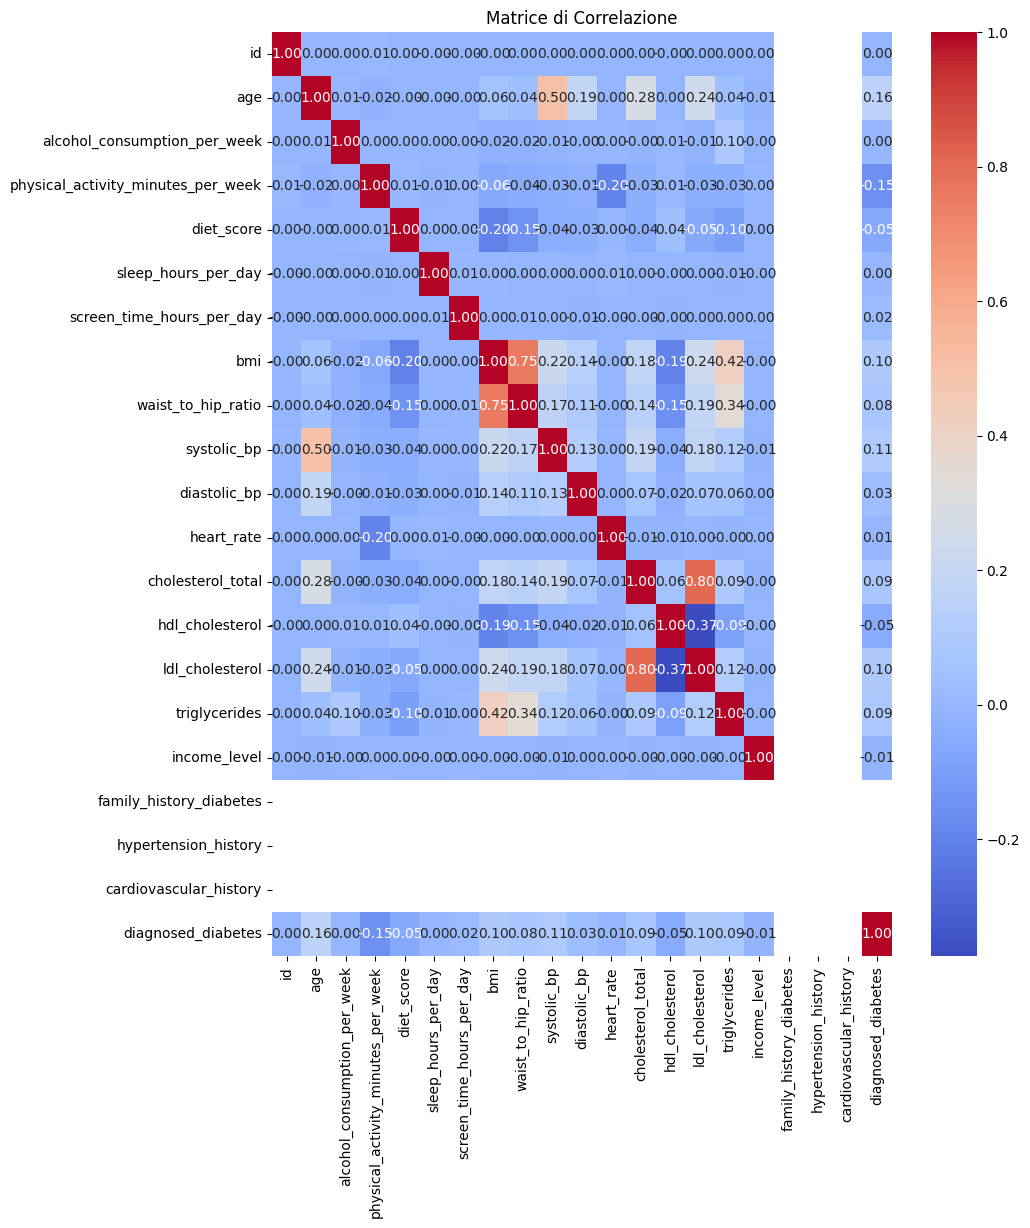

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 12))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di Correlazione')
plt.show()



### 1. Indicatori di Insulino-Resistenza e Rischio Lipidico (Fondamentali)

Il profilo lipidico standard (Totale, HDL, LDL, Trigliceridi) è utile, ma nel diabete di tipo 2 la "dislipidemia diabetica" è specifica. Ecco cosa calcolare:

* **Rapporto Trigliceridi / HDL ($TG/HDL Ratio$)**
    * **Formula:** $\frac{\text{triglycerides}}{\text{hdl\_cholesterol}}$
    * **Significato medico:** È uno dei più potenti marker surrogati dell'**insulino-resistenza**. Un valore elevato (generalmente $> 2.5$ o $3.0$ se in mg/dL) è fortemente correlato a particelle LDL piccole e dense (più pericolose) e iperinsulinemia, anche prima che il diabete venga diagnosticato.
* **Colesterolo Non-HDL**
    * **Formula:** $\text{cholesterol\_total} - \text{hdl\_cholesterol}$
    * **Significato medico:** Le linee guida attuali per il diabete lo considerano un target terapeutico secondario cruciale. Rappresenta tutto il colesterolo "cattivo" (LDL + VLDL + IDL). È spesso un predittore di rischio cardiovascolare migliore dell'LDL da solo nei pazienti diabetici.
* **Rapporto Colesterolo Totale / HDL (Castelli Risk Index I)**
    * **Formula:** $\frac{\text{cholesterol\_total}}{\text{hdl\_cholesterol}}$
    * **Significato medico:** Valuta il rischio cardiovascolare globale. Nel diabetico, vogliamo mantenere questo rapporto il più basso possibile ($< 3.5$ idealmente).

### 2. Indicatori Emodinamici (Pressione Sanguigna)

L'ipertensione e il diabete viaggiano spesso insieme.

* **Pressione Differenziale (Pulse Pressure - PP)**
    * **Formula:** $\text{systolic\_bp} - \text{diastolic\_bp}$
    * **Significato medico:** Indica la rigidità arteriosa. Nel diabete, le arterie tendono a indurirsi prima. Una PP ampia ($> 60$ mmHg) è un fattore di rischio indipendente per eventi cardiaci e danni ai reni (nefropatia diabetica).
* **Pressione Arteriosa Media (MAP)**
    * **Formula:** $\text{diastolic\_bp} + \frac{1}{3}(\text{systolic\_bp} - \text{diastolic\_bp})$
    * **Significato medico:** Indica la pressione di perfusione degli organi vitali. È utile per valutare il carico cronico sul sistema vascolare.

### 3. Indicatori di Stile di Vita e Obesità Viscerale

Oltre al BMI (che non distingue tra muscolo e grasso) e al `waist_to_hip_ratio` (già presente e ottimo), possiamo combinare i fattori comportamentali.

* **Indice di Sedentarietà Relativa**
    * **Formula:** $\frac{\text{screen\_time\_hours\_per\_day} \times 7}{\text{physical\_activity\_minutes\_per\_week} / 60}$
    * *Nota:* Stiamo convertendo tutto in ore settimanali per avere un rapporto adimensionale o comparabile.
    * **Significato medico:** Il diabete è fortemente legato non solo alla mancanza di attività, ma al tempo trascorso seduti. Un alto rapporto indica un fenotipo ad alto rischio metabolico.
* **Interaction Term: BMI $\times$ Età**
    * **Significato medico:** L'impatto del BMI sul rischio di diabete cambia con l'età. Un BMI alto in giovane età è molto più predittivo per lo sviluppo precoce del diabete rispetto a un BMI alto in età avanzata. Creare questa variabile di interazione può aiutare i modelli di machine learning a catturare questa sfumatura.

### 4. Score di Sindrome Metabolica (Proxy)

Poiché hai quasi tutti i componenti della Sindrome Metabolica (tranne la glicemia a digiuno, ma hai l'outcome), puoi creare un punteggio di rischio (0-4) sommando le seguenti condizioni booleane (soglie basate su criteri ATP III / IDF):

1.  **Obesità addominale:** `waist_to_hip_ratio` $> 0.90$ (uomini) o $> 0.85$ (donne) [o usare BMI $> 30$ se WHR non è standardizzato].
2.  **Trigliceridi alti:** `triglycerides` $\ge 150$ mg/dL.
3.  **HDL basso:** `hdl_cholesterol` $< 40$ (uomini) o $< 50$ (donne).
4.  **Pressione alta:** `systolic_bp` $\ge 130$ oppure `diastolic_bp` $\ge 85$ (oppure `hypertension_history` == 1).

**Perché calcolarlo?** Più alto è questo punteggio, esponenzialmente più alto è il rischio di conversione in diabete franco o complicazioni.

### Riassunto per il tuo codice (Python/Pandas):

Se vuoi implementare subito i più impattanti, ecco come trasformerei il DataFrame:

1.  `TG_HDL_Ratio` (Trigliceridi / HDL) -> **Top Priority**
2.  `Non_HDL_Cholesterol` (Totale - HDL)
3.  `Pulse_Pressure` (Sistolica - Diastolica)
4.  `Metabolic_Syndrome_Score` (Somma dei fattori di rischio sopra citati)


In [ ]:
df_eng = df.copy()

# ==========================================================================
# 0. GESTIONE SESSO (Logica One-Hot)
# ==========================================================================
# Definiamo le maschere booleane per identificare i gruppi.

# 1. Identifichiamo gli UOMINI
is_male = df_eng['gender_Male'] == 1

# 2. Identifichiamo "ALTRO" (Solo se la colonna esiste!)
if 'gender_Other' in df_eng.columns:
    is_other = df_eng['gender_Other'] == 1
else:
    # Se non c'è la colonna, assumiamo False per tutti (nessun "Other" rilevato)
    is_other = pd.Series(False, index=df_eng.index)
    # Nota: Se avevi 'Other' nel dataset originale e l'hai persa col get_dummies,
    # qui verranno trattati come Donne.

# 3. Identifichiamo le DONNE
# Sono coloro che NON sono uomini E NON sono altro
is_female = (~is_male) & (~is_other)

# ==========================================================================
# 1. INDICATORI LIPIDICI (Invariati)
# ==========================================================================
epsilon = 1e-6
df_eng['tg_hdl_ratio'] = df_eng['triglycerides'] / (df_eng['hdl_cholesterol'] + epsilon)
df_eng['non_hdl_cholesterol'] = df_eng['cholesterol_total'] - df_eng['hdl_cholesterol']
df_eng['castelli_risk_index_1'] = df_eng['cholesterol_total'] / (df_eng['hdl_cholesterol'] + epsilon)

# ==========================================================================
# 2. INDICATORI EMODINAMICI (Invariati)
# ==========================================================================
df_eng['pulse_pressure'] = df_eng['systolic_bp'] - df_eng['diastolic_bp']
df_eng['mean_arterial_pressure'] = df_eng['diastolic_bp'] + (df_eng['pulse_pressure'] / 3)


# ==========================================================================
# 3. STILE DI VITA (Invariati)
# ==========================================================================
activity_hours = df_eng['physical_activity_minutes_per_week'] / 60
screen_time_week = df_eng['screen_time_hours_per_day'] * 7
df_eng['sedentary_index'] = screen_time_week / (activity_hours + epsilon)
df_eng['bmi_age_interaction'] = df_eng['bmi'] * df_eng['age']

# ==========================================================================
# 4. SCORE SINDROME METABOLICA (ADATTATO CON NP.SELECT)
# ==========================================================================

# Usiamo np.select per applicare le soglie condizionali in base alle maschere create sopra.
# Ordine condizioni: [Se è Maschio, Se è Donna, (Default/Other)]
# Nota: Se is_other è tutto False, il ramo 'default' non verrà mai attivato se copriamo M e F.
# Quindi strutturiamo: [Maschio, Femmina], default=Other

conditions = [is_male, is_female]

# --- A. Obesità Addominale (WHR) ---
# Uomo > 0.90, Donna > 0.85, Altro = 0.875
whr_thresholds = [0.90, 0.85]
limit_whr = np.select(conditions, whr_thresholds, default=0.875)

df_eng['bool_abdominal_obesity'] = (df_eng['waist_to_hip_ratio'] > limit_whr).astype(int)

# --- B. Trigliceridi Alti ---
# >= 150 per tutti
df_eng['bool_high_triglycerides'] = (df_eng['triglycerides'] >= 150).astype(int)

# --- C. HDL Basso ---
# Uomo < 40, Donna < 50, Altro < 45
hdl_thresholds = [40, 50]
limit_hdl = np.select(conditions, hdl_thresholds, default=45)

df_eng['bool_low_hdl'] = (df_eng['hdl_cholesterol'] < limit_hdl).astype(int)

# --- D. Pressione Alta ---
# >= 130/85 (Uguale per tutti)
df_eng['bool_high_bp'] = (
    (df_eng['systolic_bp'] >= 130) | 
    (df_eng['diastolic_bp'] >= 85) | 
    (df_eng['hypertension_history'] == 1)
).astype(int)

# --- Calcolo Score ---
df_eng['metabolic_syndrome_score'] = (
    df_eng['bool_abdominal_obesity'] + 
    df_eng['bool_high_triglycerides'] + 
    df_eng['bool_low_hdl'] + 
    df_eng['bool_high_bp']
)

# ==========================================================================
# 5. INDICATORI DI STRESS CARDIACO E CARICO
# ==========================================================================
# Rate Pressure Product (RPP) o Doppio Prodotto
# Formula: Frequenza Cardiaca * Pressione Sistolica
# Significato: È un indice del consumo di ossigeno del miocardio.
# Nei diabetici, un RPP alto a riposo indica un sistema nervoso simpatico iperattivo.
df_eng['rate_pressure_product'] = df_eng['heart_rate'] * df_eng['systolic_bp']

# Logaritmo dei Trigliceridi
# Significato: I trigliceridi hanno spesso una distribuzione asimmetrica (skewed).
# Il rischio cardiovascolare scala logaritmicamente, non linearmente.
df_eng['log_triglycerides'] = np.log(df_eng['triglycerides'] + 1)

# ==========================================================================
# 6. INDICATORI DI FORMA FISICA COMPLESSA (Proxy Viscerale)
# ==========================================================================
# Poiché non abbiamo la circonferenza vita assoluta (in cm) ma solo il rapporto (WHR),
# e abbiamo il BMI, possiamo creare un termine di interazione.
# Significato: Distingue un BMI alto dovuto a muscoli (WHR basso) 
# da un BMI alto dovuto a grasso viscerale (WHR alto).
df_eng['visceral_adiposity_proxy'] = df_eng['bmi'] * df_eng['waist_to_hip_ratio']

# ==========================================================================
# 7. CURVA DEL SONNO (Relazione a U)
# ==========================================================================
# Il rischio diabete rispetto al sonno non è lineare. Dormire poco fa male, 
# ma dormire troppo fa altrettanto male (spesso indice di depressione o apnea).
# Creiamo la distanza dall'ottimale (7.5 ore).
# Più alto è il valore, peggiore è la condizione.
df_eng['sleep_deviation'] = (df_eng['sleep_hours_per_day'] - 7.5).abs()

# ==========================================================================
# 8. SCORE DI CARICO STORICO/COMORBIDITÀ
# ==========================================================================
# Somma semplice dei fattori di rischio storici/genetici.
# Rappresenta il "carico allostatico" o la fragilità del paziente.
df_eng['comorbidity_burden'] = (
    df_eng['family_history_diabetes'] + 
    df_eng['hypertension_history'] + 
    df_eng['cardiovascular_history']
)

# ==========================================================================
# 9. RAPPORTO DI RISCHIO COMPLETO (Lipidico-Emodinamico)
# ==========================================================================
# Un tentativo di creare un super-feature che combini stress vascolare e metabolico.
# (Sistolica * Trigliceridi) / HDL
# Questo amplifica i pazienti con "Tempesta Metabolica" (Pressione alta + Grassi alti + HDL basso)
df_eng['metabolic_stress_index'] = (
    (df_eng['systolic_bp'] * df_eng['triglycerides']) / (df_eng['hdl_cholesterol'] + epsilon)
)

df_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453333 entries, 0 to 699999
Data columns (total 53 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  453333 non-null  float64
 1   age                                 453333 non-null  float64
 2   alcohol_consumption_per_week        453333 non-null  float64
 3   physical_activity_minutes_per_week  453333 non-null  float64
 4   diet_score                          453333 non-null  float64
 5   sleep_hours_per_day                 453333 non-null  float64
 6   screen_time_hours_per_day           453333 non-null  float64
 7   bmi                                 453333 non-null  float64
 8   waist_to_hip_ratio                  453333 non-null  float64
 9   systolic_bp                         453333 non-null  float64
 10  diastolic_bp                        453333 non-null  float64
 11  heart_rate                     

In [ ]:
def objective(trial):
    '''
    params = {
        # --- Config Hardware ---
        'device_type': 'cpu', 
        'n_jobs': -1,
        'verbose': -1,

        # --- Config velocità ---
        'max_bin': 255,          
        'bagging_freq': 1,
        'bagging_fraction': 0.8,

        # --- Parametri Modello ---
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        
        # --- Search Space (Ridotto per convergere prima) ---
        'n_estimators': 1000, # Abbassato il tetto massimo
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True), # LR più alto = impara prima
        'num_leaves': trial.suggest_int('num_leaves', 20, 100), # Meno foglie = alberi più semplici
        'max_depth': trial.suggest_int('max_depth', 3, 8),      # Alberi meno profondi
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 1000),
        
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    '''
    params = {
        'objective': 'binary:logistic',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000), # Intero tra 100 e 1000
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True), # Scala logaritmica
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # % feature per albero
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # L1 Reg (Lasso)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2 Reg (Ridge)
        'n_jobs': 3,
        'random_state': 42
    }
    
    
    #model = lgb.LGBMClassifier(**params)
    model = xgb.XGBClassifier(**params)
    
    # Callback Pruning
    #pruning_callback = LightGBMPruningCallback(trial, "auc")
    
    #model.fit(
        #X_train, y_train,
        #eval_set=[(X_val, y_val)],
        #eval_metric='auc',
        #callbacks=[
            # Smetti subito se non migliori per 10 round (molto aggressivo)
            #lgb.early_stopping(stopping_rounds=10, verbose=False),
            #pruning_callback
        #]
    #)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    if trial.should_prune():
            raise optuna.TrialPruned()
    
    #preds = model.predict(X_val)
    #accuracy = np.mean(preds == y_val)
    
    return scores.mean()


In [ ]:
df_demo = df_eng.sample(frac=1, random_state=42)

X = df_demo.drop(columns=["diagnosed_diabetes"], axis=1)
y = df_demo["diagnosed_diabetes"]

# Ottimizzazione Memoria
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype('float32')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# --- Studio ---
print("--- Inizio Demo Rapida (Hyperband + 10% Dati) ---")

# HyperbandPruner è perfetto per le demo: prova tanti parametri all'inizio con poche risorse
# e uccide spietatamente quelli che non promettono bene.
study = optuna.create_study(
    direction='maximize', 
    pruner=optuna.pruners.MedianPruner( n_startup_trials=5, n_warmup_steps=30, interval_steps=10),
    #pruner=optuna.pruners.HyperbandPruner(min_resource=1, max_resource='auto', reduction_factor=3)
)

# 30 tentativi dovrebbero finire in 1-3 minuti con queste impostazioni se si usa model = lgb.LGBMClassifier(**params)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nMiglior Accuratezza (sul sample ridotto): {study.best_value:.4f}")
print("Migliori Parametri:", study.best_params)

[I 2025-12-05 17:34:15,339] A new study created in memory with name: no-name-d6d74090-d024-45ba-9671-57f8dfb3e64f


--- Inizio Demo Rapida (Hyperband + 10% Dati) ---


Best trial: 0. Best value: 0.641353:   3%|▎         | 1/30 [01:09<33:31, 69.35s/it]

[I 2025-12-05 17:35:24,694] Trial 0 finished with value: 0.6413532027242755 and parameters: {'n_estimators': 998, 'learning_rate': 0.03665007214886818, 'max_depth': 9, 'subsample': 0.875728137011909, 'colsample_bytree': 0.9185896850453015, 'reg_alpha': 3.6733272273417823e-06, 'reg_lambda': 0.0002652597900853753}. Best is trial 0 with value: 0.6413532027242755.


Best trial: 0. Best value: 0.641353:   7%|▋         | 2/30 [01:53<25:33, 54.75s/it]

...

[I 2025-12-05 17:48:08,652] Trial 27 finished with value: 0.6415875778510014 and parameters: {'n_estimators': 631, 'learning_rate': 0.052803048044388005, 'max_depth': 9, 'subsample': 0.833860945608184, 'colsample_bytree': 0.609968778744188, 'reg_alpha': 6.442460370364725, 'reg_lambda': 1.0664453400533463e-08}. Best is trial 26 with value: 0.6436335383839181.


Best trial: 26. Best value: 0.643634:  97%|█████████▋| 29/30 [14:27<00:34, 34.70s/it]

[I 2025-12-05 17:48:42,891] Trial 28 finished with value: 0.6424864808655152 and parameters: {'n_estimators': 512, 'learning_rate': 0.01843243346484382, 'max_depth': 8, 'subsample': 0.9019147593971375, 'colsample_bytree': 0.700547322027808, 'reg_alpha': 1.5781328815533986, 'reg_lambda': 9.10835042241438e-06}. Best is trial 26 with value: 0.6436335383839181.


Best trial: 26. Best value: 0.643634: 100%|██████████| 30/30 [15:37<00:00, 31.23s/it]

[I 2025-12-05 17:49:52,388] Trial 29 finished with value: 0.6419239747070936 and parameters: {'n_estimators': 725, 'learning_rate': 0.0366880149436958, 'max_depth': 10, 'subsample': 0.8624760312093909, 'colsample_bytree': 0.7786559024649261, 'reg_alpha': 7.49095459161646, 'reg_lambda': 0.000333200826868848}. Best is trial 26 with value: 0.6436335383839181.

Miglior Accuratezza (sul sample ridotto): 0.6436
Migliori Parametri: {'n_estimators': 624, 'learning_rate': 0.051554055966734645, 'max_depth': 8, 'subsample': 0.9724862745117875, 'colsample_bytree': 0.8357426142531679, 'reg_alpha': 7.6855328252402355, 'reg_lambda': 0.000821189472602618}


Addestramento modello finale con parametri: {'device_type': 'cpu', 'n_jobs': -1, 'verbose': -1, 'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'n_estimators': 624, 'learning_rate': 0.051554055966734645, 'max_depth': 8, 'subsample': 0.9724862745117875, 'colsample_bytree': 0.8357426142531679, 'reg_alpha': 7.6855328252402355, 'reg_lambda': 0.000821189472602618}

--- Report Finale ---
Accuratezza sul Test Set: 0.6431

Dettagli per classe:
              precision    recall  f1-score   support

         0.0       0.60      0.44      0.51     38032
         1.0       0.66      0.79      0.72     52635

    accuracy                           0.64     90667
   macro avg       0.63      0.62      0.61     90667
weighted avg       0.64      0.64      0.63     90667



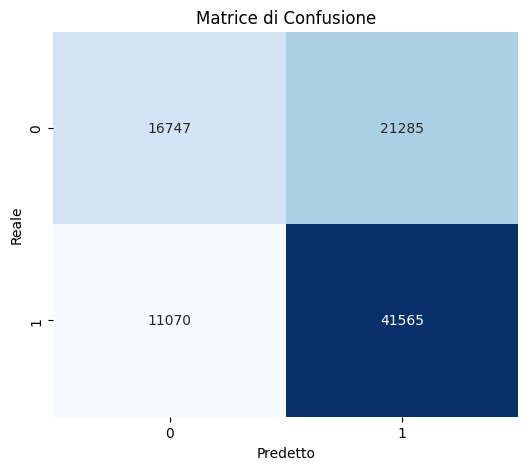

In [ ]:
# 1. Recuperiamo i parametri migliori trovati da Optuna
best_params = study.best_params

# 2. Aggiungiamo i parametri "fissi" (GPU, obiettivo, ecc.) che non abbiamo ottimizzato
fixed_params = {
    'device_type': 'cpu', 
    'n_jobs': -1,
    'verbose': -1,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42
}

# Uniamo i due dizionari (i parametri fissi + i migliori trovati)
final_params = {**fixed_params, **best_params}

print(f"Addestramento modello finale con parametri: {final_params}")

# 3. Addestramento Finale
#final_model = lgb.LGBMClassifier(**final_params)
final_model = xgb.XGBClassifier(**best_params, n_jobs=-1, random_state=42)
final_model.fit(X_train, y_train)

# 4. Valutazione
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- Report Finale ---")
print(f"Accuratezza sul Test Set: {acc:.4f}")
print("\nDettagli per classe:")
print(classification_report(y_test, y_pred))

# 5. Grafico Matrice di Confusione (Ottimo per le presentazioni)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice di Confusione')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()